<a href="https://colab.research.google.com/github/lichagogoi/Tsetlin_Machine_URL_classification/blob/main/TM1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 13.2 MB/s eta 0:00:00


In [ ]:
!pip install tmu
!pip uninstall numpy -y
!pip install numpy==1.26.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 kB 2.8 MB/s eta 0:00:00
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 919.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 37.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python

In [ ]:
import numpy as np
from tmu.models.classification.vanilla_classifier import TMClassifier
from sklearn.model_selection import train_test_split
import argparse
from datetime import datetime
import random
from sklearn.utils import shuffle
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
import numpy as np
from statistics import mean, stdev
from scipy.stats import linregress
from tmu.preprocessing.standard_binarizer.binarizer import StandardBinarizer

ERROR:tmu.clause_bank.clause_bank_cuda:No module named 'pycuda'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'


In [ ]:

!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get install -y --reinstall ttf-mscorefonts-installer
!fc-cache -f -v

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ubuntu-advantage-tools ubuntu-pro-client
  ubuntu-pro-client-l10n ubuntu-release-upgrader-core update-manager-core
  update-notifier-common xfonts-encodings xfonts-utils zstd
Suggested packages:
  shunit2
The following NEW packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ttf-mscorefonts-installer
  ubuntu-advantage-tools ubuntu-pro-client ubuntu-pro-client-l10n
  ubuntu-release-upgrader-core update-manager-core update-notifier-common
  xfonts-encodings xfonts-utils zstd
0 upgraded, 20 newly installed, 0 to remove and 3 not upgraded.
Need t

In [ ]:
import os
import pandas as pd
from datetime import datetime


os.makedirs("experiments", exist_ok=True)


LOG_FILE = "experiments/experiment_master_log.csv"

def log_experiment_to_csv(config, final_metrics):
    """Saves hyperparameters and final results to a permanent master CSV."""

    row_data = {**config, **final_metrics, "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
    df_new = pd.DataFrame([row_data])

    if not os.path.exists(LOG_FILE):
        df_new.to_csv(LOG_FILE, index=False)
    else:
        df_new.to_csv(LOG_FILE, mode='a', header=False, index=False)
    print(f"Logged experiment details to {LOG_FILE}")

In [ ]:

import os


FILE_ID = "1cdxR12vGaNtzugu-dLnTBLJI7V4UCJW4"
LOCAL_FILE = "All.csv"


if not os.path.exists(LOCAL_FILE):
    print("Downloading dataset directly from Google Drive...")

    !wget --no-check-certificate 'https://docs.google.com/uc?export=download&id={FILE_ID}' -O {LOCAL_FILE}
    print("Download complete!")
else:
    print("Dataset already present in Colab.")

--2026-07-10 03:21:50--  https://docs.google.com/uc?export=download&id=1cdxR12vGaNtzugu-dLnTBLJI7V4UCJW4
Resolving docs.google.com (docs.google.com)... 108.177.97.113, 108.177.97.101, 108.177.97.139, ...
Connecting to docs.google.com (docs.google.com)|108.177.97.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1cdxR12vGaNtzugu-dLnTBLJI7V4UCJW4&export=download [following]
--2026-07-10 03:21:50--  https://drive.usercontent.google.com/download?id=1cdxR12vGaNtzugu-dLnTBLJI7V4UCJW4&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.8.132, 2404:6800:4008:c15::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.8.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11661240 (11M) [application/octet-stream]
Saving to: ‘All.csv’

All.csv             100%[===================>]  11.12M  30.1MB/s    in 0.4s   

In [ ]:
!ls


drive  sample_data


In [ ]:

import pandas as pd
df = pd.read_csv('All.csv')

print(f"Original number of rows: {len(df)}")


features = df.drop(columns=['URL_Type_obf_Type'])

features_imputed = features.fillna(features.mean(numeric_only=True))

df_cleaned = features_imputed.copy()
df_cleaned['URL_Type_obf_Type'] = df['URL_Type_obf_Type']


df_cleaned = df_cleaned.fillna(0)

print(f"Number of rows after : {len(df_cleaned)}")

Original number of rows: 36707
Number of rows after : 36707


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

def process_csv_with_thermometer_binarizer(df_input, num_bins=15, test_size=0.2, random_state=42):
    """
    Binarizes continuous features using Thermometer Encoding.
    Each continuous feature is mapped to a sequence of 'num_bins' bits.
    """
    df = df_input.copy()


    X = df.drop(columns=['URL_Type_obf_Type'])
    Y = df['URL_Type_obf_Type']

    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X = X.fillna(X.mean(numeric_only=True))
    X = X.fillna(0)

    encoder = LabelEncoder()
    Y = encoder.fit_transform(Y)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    x_train_bits = []
    x_test_bits = []

    for col in X.columns:
        percentiles = np.linspace(0, 100, num_bins + 1)[1:-1]
        thresholds = np.percentile(X_train_raw[col], percentiles)
        thresholds = np.unique(thresholds)

        train_matrix = X_train_raw[col].values[:, np.newaxis] > thresholds
        x_train_bits.append(train_matrix.astype(np.uint32))


        test_matrix = X_test_raw[col].values[:, np.newaxis] > thresholds
        x_test_bits.append(test_matrix.astype(np.uint32))

    x_train_binary = np.hstack(x_train_bits)
    x_test_binary = np.hstack(x_test_bits)

    data_dict = {
        "x_train": x_train_binary,
        "x_test": x_test_binary,
        "y_train": y_train.astype(np.uint32),
        "y_test": y_test.astype(np.uint32),
    }

    print(f"Thermometer encoding complete.")
    print(f"Generated Binary Feature Shape: {x_train_binary.shape[1]} total bits per sample.")
    return data_dict


In [ ]:
from sklearn.preprocessing import LabelEncoder

temp_encoder = LabelEncoder()
temp_encoder.fit(df['URL_Type_obf_Type'])

for index, class_name in enumerate(temp_encoder.classes_):
     print(f"Integer {index} ----> Label: {class_name}")

Integer 0 ----> Label: Defacement
Integer 1 ----> Label: benign
Integer 2 ----> Label: malware
Integer 3 ----> Label: phishing
Integer 4 ----> Label: spam


In [ ]:
df_raw = pd.read_csv("All.csv")

url_data_dict = process_csv_with_thermometer_binarizer(df_raw)

Thermometer encoding complete.
Generated Binary Feature Shape: 640 total bits per sample.


In [ ]:
data = url_data_dict
x_train, y_train = data['x_train'], data['y_train']
x_test, y_test = data['x_test'], data['y_test']

In [ ]:
import pandas as pd
import numpy as np


class_counts = df_cleaned['URL_Type_obf_Type'].value_counts()
class_proportions = df_cleaned['URL_Type_obf_Type'].value_counts(normalize=True) * 100

print("=" * 60)
print("            DATASET PROFILE REPORT FOR APPENDIX")
print("=" * 60)
for label in class_counts.index:
    print(f"Class: {label:<12} | Count: {class_counts[label]:>6} | Share: {class_proportions[label]:.2f}%")
print("=" * 60)

            DATASET PROFILE REPORT FOR APPENDIX
Class: Defacement   | Count:   7930 | Share: 21.60%
Class: benign       | Count:   7781 | Share: 21.20%
Class: phishing     | Count:   7586 | Share: 20.67%
Class: malware      | Count:   6712 | Share: 18.29%
Class: spam         | Count:   6698 | Share: 18.25%


In [ ]:
x_train.shape

(29365, 640)

In [ ]:
np.unique(y_train)


array([0, 1, 2, 3, 4], dtype=uint32)

In [ ]:
def tm_classifier(
    number_of_clauses=100,
    T=75,
    s=3.0,
    platform="CPU",
    weighted_clauses=True,
    feature_negation=True
):
    return TMClassifier(
        number_of_clauses=number_of_clauses,
        T=T,
        s=s,
        platform=platform,
        weighted_clauses=weighted_clauses,
        feature_negation=feature_negation
    )

In [ ]:
config = {
    "clauses": 100,
    "T": 75,
    "s": 3.0,
    "epochs": 100,
    "binarizer": "Tree_Depth_5"
}

run_suffix = f"c{config['clauses']}_T{config['T']}_s{config['s']}"

tm = tm_classifier(
    number_of_clauses=config["clauses"],
    T=config["T"],
    s=config["s"],
    platform="CPU"
)

for i in range(100):
    batch_data_log = {}
    tm.fit(x_train, y_train)
    tm_test_pred, tm_test_scores = tm.predict(x_test, return_class_sums=True)
    acc = 100 * (tm_test_pred == y_test).mean()
    if (i % 10 == 0):
        print(f'epoch - {i} : accuracy = {acc}')

epoch - 0 : accuracy = 85.56251702533369
epoch - 10 : accuracy = 93.38055025878506
epoch - 20 : accuracy = 93.80277853445928
epoch - 30 : accuracy = 94.76981748842277
epoch - 40 : accuracy = 95.08308362843911
epoch - 50 : accuracy = 94.22500681013348
epoch - 60 : accuracy = 94.52465268319258
epoch - 70 : accuracy = 95.02860256061018
epoch - 80 : accuracy = 95.19204576409697
epoch - 90 : accuracy = 95.20566603105421


In [ ]:
epochs = 100
train_accuracies = []
test_accuracies = []
train_times = []
infer_times = []

for epoch in range(epochs):

    if epoch >= 35:

        tm.s = 0.001

    start_train = time.time()
    tm.fit(data["x_train"], data["y_train"], epochs=1)
    train_time = time.time() - start_train
    train_times.append(train_time)

    y_train_pred = tm.predict(data["x_train"])
    train_acc = 100 * accuracy_score(data["y_train"], y_train_pred)
    train_accuracies.append(train_acc)

    start_infer = time.time()
    y_test_pred = tm.predict(data["x_test"])
    infer_time = time.time() - start_infer
    infer_times.append(infer_time)

    test_acc = 100 * accuracy_score(data["y_test"], y_test_pred)
    test_accuracies.append(test_acc)

In [ ]:
literal_freq = tm.literal_clause_frequency()
print(literal_freq)


[4 1 0 ... 5 5 5]


In [ ]:
literal_freq.shape

(1280,)

In [ ]:
epochs = 100
best_acc=0.0
train_accuracy_history = []
test_accuracy_history = []
for epoch in range(epochs):

    tm.fit(x_train, y_train)

    # Calculate accuracy on Training data
    preds_train = tm.predict(x_train)
    train_acc = (preds_train == y_train).mean() * 100
    train_accuracy_history.append(train_acc)

    # Calculate accuracy on Testing data
    preds_test = tm.predict(x_test)
    test_acc = (preds_test == y_test).mean() * 100
    test_accuracy_history.append(test_acc)


    if test_acc > best_acc:
        best_acc = test_acc

    print(f"Epoch {epoch:02d} -> Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% (Peak: {best_acc:.2f}%)")



Epoch 00 -> Train Acc: 96.65% | Test Acc: 94.91% (Peak: 94.91%)
Epoch 01 -> Train Acc: 96.71% | Test Acc: 95.41% (Peak: 95.41%)
Epoch 02 -> Train Acc: 97.00% | Test Acc: 95.71% (Peak: 95.71%)
Epoch 03 -> Train Acc: 96.62% | Test Acc: 95.27% (Peak: 95.71%)
Epoch 04 -> Train Acc: 96.64% | Test Acc: 95.51% (Peak: 95.71%)
Epoch 05 -> Train Acc: 96.80% | Test Acc: 95.29% (Peak: 95.71%)
Epoch 06 -> Train Acc: 96.68% | Test Acc: 95.03% (Peak: 95.71%)
Epoch 07 -> Train Acc: 96.34% | Test Acc: 94.93% (Peak: 95.71%)
Epoch 08 -> Train Acc: 96.67% | Test Acc: 94.99% (Peak: 95.71%)
Epoch 09 -> Train Acc: 96.93% | Test Acc: 95.37% (Peak: 95.71%)
Epoch 10 -> Train Acc: 96.82% | Test Acc: 95.14% (Peak: 95.71%)
Epoch 11 -> Train Acc: 96.88% | Test Acc: 94.93% (Peak: 95.71%)
Epoch 12 -> Train Acc: 96.78% | Test Acc: 95.18% (Peak: 95.71%)
Epoch 13 -> Train Acc: 97.08% | Test Acc: 95.46% (Peak: 95.71%)
Epoch 14 -> Train Acc: 96.81% | Test Acc: 95.36% (Peak: 95.71%)
Epoch 15 -> Train Acc: 96.76% | Test Acc

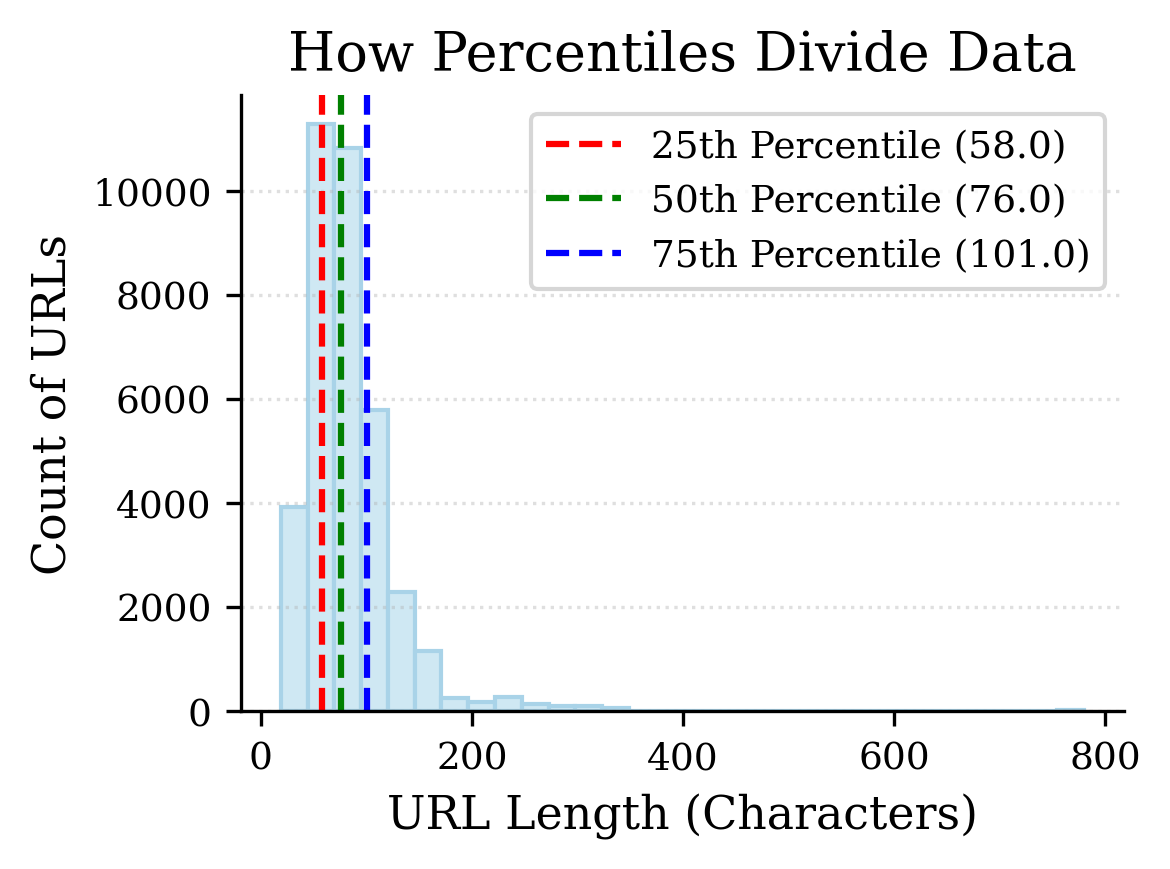

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("All.csv")
data = df['urlLen'].dropna().values

p25, p50, p75 = np.percentile(data, [25, 50, 75])


p99 = np.percentile(data, 99)
plot_data = data[data <= p99]


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Liberation Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']

fig, ax = plt.subplots(figsize=(4,3), dpi=300)
ax.hist(plot_data, bins=30, color="#cfe8f3", edgecolor="#a9d3e8")

ax.axvline(p25, color="red", linestyle="--", linewidth=1.5,
           label=f"25th Percentile ({p25:.1f})")
ax.axvline(p50, color="green", linestyle="--", linewidth=1.5,
           label=f"50th Percentile ({p50:.1f})")
ax.axvline(p75, color="blue", linestyle="--", linewidth=1.5,
           label=f"75th Percentile ({p75:.1f})")

ax.set_title("How Percentiles Divide Data", fontsize=13)
ax.set_xlabel("URL Length (Characters)", fontsize=11)
ax.set_ylabel("Count of URLs", fontsize=11)
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, loc="upper right", frameon=True)
ax.grid(axis="y", linestyle=":", alpha=0.4)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("quantile_thermometer_fig.pdf", format="pdf", bbox_inches="tight")
plt.show()

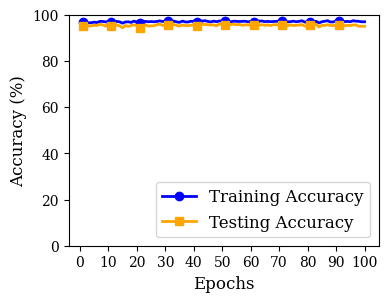

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Liberation Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']


plt.figure(figsize=(4,3))
actual_epochs = len(train_accuracy_history)


plt.plot(range(1, actual_epochs + 1), train_accuracy_history, label='Training Accuracy', color='blue', marker='o', markevery=10,linewidth=2)
plt.plot(range(1, actual_epochs + 1), test_accuracy_history, label='Testing Accuracy', color='orange', marker='s',markevery=10, linewidth=2)


plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(range(0, 101, 10))
plt.ylim(0,100)
plt.savefig(f"experiments/accuracy_{run_suffix}.pdf", format='pdf', bbox_inches='tight', pad_inches=0)
plt.savefig(f"experiments/accuracy_{run_suffix}.svg", format='svg', bbox_inches='tight', pad_inches=0)

plt.legend(fontsize=12, loc='lower right')

# Display
plt.savefig(f"experiments/curves_{run_suffix}.pdf", format='pdf', bbox_inches='tight', pad_inches=0)
plt.savefig(f"experiments/curves_{run_suffix}.svg", format='svg', bbox_inches='tight', pad_inches=0)


plt.show()

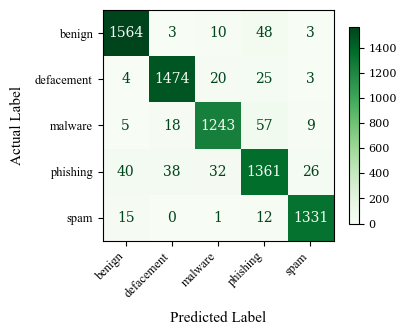

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4, 3))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format='d')

im = ax.images[0]
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.05, shrink=0.85)
cbar.ax.tick_params(labelsize=8) # smaller colorbar numbers

ax.set_xlabel("Predicted Label", fontproperties=tnr_font, fontsize=11, labelpad=8)
ax.set_ylabel("Actual Label", fontproperties=tnr_font, fontsize=11, labelpad=8)

ax.set_xticklabels(class_names, rotation=45, ha='right', fontproperties=tnr_font, fontsize=9)
ax.set_yticklabels(class_names, fontproperties=tnr_font, fontsize=9)

plt.savefig(
    f"experiments/confusion_matrix_{run_suffix}.pdf",
    format='pdf',
    bbox_inches='tight',
    pad_inches=0.02,
    dpi=300
)
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Precision, Recall, F1-score (per class)
precision_per_class = precision_score(data["y_test"], y_test_pred, average=None)
recall_per_class = recall_score(data["y_test"], y_test_pred, average=None)
f1_per_class = f1_score(data["y_test"], y_test_pred, average=None)

# Calculate weighted average scores
precision_weighted = precision_score(data["y_test"], y_test_pred, average='weighted')
recall_weighted = recall_score(data["y_test"], y_test_pred, average='weighted')
f1_weighted = f1_score(data["y_test"], y_test_pred, average='weighted')

print("Scores per class:")
for i in range(len(precision_per_class)):
    print(f"Class {i}: Precision={precision_per_class[i]:.2f}, Recall={recall_per_class[i]:.2f}, F1-score={f1_per_class[i]:.2f}")

print(f"\nWeighted Average Precision: {precision_weighted:.2f}")
print(f"Weighted Average Recall: {recall_weighted:.2f}")
print(f"Weighted Average F1-score: {f1_weighted:.2f}")

Scores per class:
Class 0: Precision=0.98, Recall=0.95, F1-score=0.96
Class 1: Precision=0.97, Recall=0.96, F1-score=0.96
Class 2: Precision=0.96, Recall=0.94, F1-score=0.95
Class 3: Precision=0.88, Recall=0.94, F1-score=0.91
Class 4: Precision=0.98, Recall=0.97, F1-score=0.98

Weighted Average Precision: 0.95
Weighted Average Recall: 0.95
Weighted Average F1-score: 0.95


In [ ]:
import os
import optuna
import numpy as np
from tmu.models.classification.vanilla_classifier import TMClassifier


os.makedirs("experiments", exist_ok=True)

# Lock down your training boundaries using your working global variables
X_train_fixed = x_train
X_test_fixed = x_test
Y_train_fixed = y_train
Y_test_fixed = y_test

def objective(trial):

    clauses = trial.suggest_int('number_of_clauses', 50, 5000, step=50)


    t_min = int(0.20 * clauses)
    t_max = int(1.50 * clauses)
    T = trial.suggest_int('T', t_min, t_max)


    s = trial.suggest_float('s', 1.0, 10.0)


    tm_trial = TMClassifier(
        number_of_clauses=clauses,
        T=T,
        s=s,
        platform="CPU",
        weighted_clauses=True,
        feature_negation=True
    )


    num_eval_epochs = 15
    for epoch in range(num_eval_epochs):
        tm_trial.fit(X_train_fixed, Y_train_fixed)


    preds_test = tm_trial.predict(X_test_fixed)


    if isinstance(preds_test, tuple):
        preds_test = preds_test[0]

    accuracy = (preds_test == Y_test_fixed).mean()
    return accuracy


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, n_jobs=1)


best_trial = study.best_trial

report_content = f"""==================================================
OPTUNA HYPERPARAMETER OPTIMIZATION REPORT
==================================================
Binarization Strategy: Quantile / Thermometer Encoding
Best Trial Number: {best_trial.number}
Peak Validation Accuracy: {best_trial.value * 100:.2f}%

OPTIMIZED PARAMETERS:
--------------------
- number_of_clauses : {best_trial.params['number_of_clauses']}
- T (Threshold)     : {best_trial.params['T']}
- s (Specificity)   : {best_trial.params['s']:.4f}
=================================================="""

print("\n" + report_content)


report_path = "experiments/optuna_best_hyperparameters.txt"
with open(report_path, "w") as f:
    f.write(report_content)

print(f"\nSuccessfully logged structural tuning report to: {report_path}")

[I 2026-07-10 03:42:54,157] A new study created in memory with name: no-name-a0999b11-c0d8-4a31-a657-d3c60a422d3b
[I 2026-07-10 03:56:31,272] Trial 0 finished with value: 0.9686733859983656 and parameters: {'number_of_clauses': 1900, 'T': 1819, 's': 1.2560162138093527}. Best is trial 0 with value: 0.9686733859983656.
[I 2026-07-10 03:58:29,443] Trial 1 finished with value: 0.962135657858894 and parameters: {'number_of_clauses': 700, 'T': 823, 's': 8.282264436776817}. Best is trial 0 with value: 0.9686733859983656.
[I 2026-07-10 04:09:22,751] Trial 2 finished with value: 0.9750749114682647 and parameters: {'number_of_clauses': 3750, 'T': 1277, 's': 5.725183232931201}. Best is trial 2 with value: 0.9750749114682647.
[I 2026-07-10 04:11:07,300] Trial 3 finished with value: 0.9584581857804413 and parameters: {'number_of_clauses': 500, 'T': 499, 's': 5.292260384574971}. Best is trial 2 with value: 0.9750749114682647.
[I 2026-07-10 04:23:52,069] Trial 4 finished with value: 0.970852628711522


OPTUNA HYPERPARAMETER OPTIMIZATION REPORT
Binarization Strategy: Quantile / Thermometer Encoding
Best Trial Number: 8
Peak Validation Accuracy: 97.60%

OPTIMIZED PARAMETERS:
--------------------
- number_of_clauses : 4700
- T (Threshold)     : 1917
- s (Specificity)   : 6.6263

Successfully logged structural tuning report to: experiments/optuna_best_hyperparameters.txt


In [ ]:
!apt-get install -y ttf-mscorefonts-installer

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ttf-mscorefonts-installer is already the newest version (3.8ubuntu2).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
import matplotlib.pyplot as plt
import shutil
import os

# Clear the font cache directory
cache_dir = os.path.join(os.path.expanduser('~'), '.cache', 'matplotlib')
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

print("Cache cleared! Please restart your notebook kernel/runtime now.")

Cache cleared! Please restart your notebook kernel/runtime now.


In [ ]:
import matplotlib as mpl
import matplotlib.font_manager as fm

# 1. Clear the old font cache directory entirely
!rm -rf ~/.cache/matplotlib

# 2. Rebuild the font manager so it searches system paths again
fm._load_fontmanager(try_read_cache=False)

# 3. Explicitly check if it can locate Times New Roman now
print("Times New Roman found at:", fm.findfont("Times New Roman"))

Times New Roman found at: /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf


In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Define the system directory where ttf-mscorefonts-installer placed the fonts
ms_font_path = '/usr/share/fonts/truetype/msttcorefonts'

# 2. Manually scan and add each Times New Roman font file directly to the font manager
if os.path.exists(ms_font_path):
    for font_file in os.listdir(ms_font_path):
        if 'times' in font_file.lower() and font_file.endswith('.ttf'):
            full_path = os.path.join(ms_font_path, font_file)
            fm.fontManager.addfont(full_path)
            print(f"Successfully registered: {font_file}")
else:
    print(f"Error: Font path {ms_font_path} not found. Double-check your apt-get installation.")

# 3. Explicitly force Matplotlib to use it globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# 4. Verify it points to the correct system path now
print("\nVerified Times New Roman path:", fm.findfont("Times New Roman"))

Successfully registered: timesi.ttf
Successfully registered: Times_New_Roman.ttf
Successfully registered: Times_New_Roman_Bold.ttf
Successfully registered: timesbd.ttf
Successfully registered: times.ttf
Successfully registered: Times_New_Roman_Italic.ttf
Successfully registered: Times_New_Roman_Bold_Italic.ttf
Successfully registered: timesbi.ttf

Verified Times New Roman path: /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf


/tmp/ipykernel_2785/3506752714.py:12: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  ax_list = vis.plot_slice(study, params=["T", "number_of_clauses", "s"])


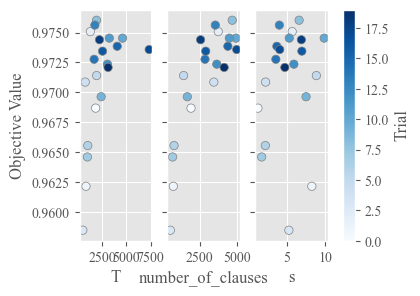

In [ ]:
import matplotlib.pyplot as plt
import optuna.visualization.matplotlib as vis
from matplotlib.font_manager import FontProperties

# Explicitly define the FontProperties configuration
tnr_font = FontProperties(family='Times New Roman', size=12)

# 1. Clear any stuck background figures
plt.close('all')

# 2. Generate the plot using Optuna's Matplotlib backend
ax_list = vis.plot_slice(study, params=["T", "number_of_clauses", "s"])

# 3. Grab the active figure created by Optuna and override its size dynamically
fig = plt.gcf()
fig.set_size_inches(4,3)

# Clear any global suptitle Optuna might have added
fig.suptitle("")

# 4. Apply your clean paper styling to the axes
for ax in fig.axes:
    # Set your Times New Roman fonts for tick labels
    ax.tick_params(labelsize=10)

    # CRUCIAL CHANGE: Remove the subplot titles entirely
    ax.set_title("")

    # Apply fonts to labels
    ax.set_xlabel(ax.get_xlabel(), fontproperties=tnr_font, fontsize=12)
    ax.set_ylabel(ax.get_ylabel(), fontproperties=tnr_font, fontsize=12)

# 5. Save crisp publication vector copies directly to your folder
plt.savefig(
    f"experiments/optuna_slice_plot_{run_suffix}.pdf",
    format='pdf',
    bbox_inches='tight',
    dpi=300
)
plt.savefig(
    f"experiments/optuna_slice_plot_{run_suffix}.svg",
    format='svg',
    bbox_inches='tight'
)

plt.show()

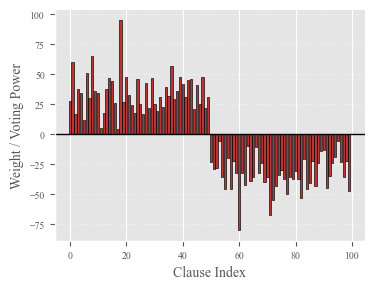

CLAUSE STRUCTURE ANALYSIS FOR 'BENIGN'
🟢 Positive Clauses (Vote FOR): 50
🔴 Negative Clauses (Vote AGAINST): 50
⚪ Inactive Clauses (Weight = 0): 0
⭐ Max Positive Voting Power: 95
⚠️ Max Negative Voting Power: -80


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Clear active figures
plt.close('all')

# 2. Register and prioritize Times New Roman globally to eliminate fallback warnings
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
fe = fm.FontEntry(fname=font_path, name='Times New Roman')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams["font.family"] = "Times New Roman"
tnr_font = fm.FontProperties(fname=font_path)

# 3. Setup configurations and extract weights from the target class bank
target_class = 0
class_name = 'benign'

clause_weights = tm.weight_banks[target_class].get_weights()
num_clauses = len(clause_weights)

# 4. Generate the Weight Layout
fig, ax = plt.subplots(figsize=(4,3))

# Use 'firebrick' (Red) for an academic, publication-ready style
ax.bar(range(num_clauses), clause_weights, color='firebrick', edgecolor='black', linewidth=0.5, alpha=0.9)

# Completely strip titles and headings
ax.set_title("")
fig.suptitle("")

# 5. Apply explicit typography styling to labels and ticks
ax.set_xlabel("Clause Index", fontproperties=tnr_font, fontsize=10)
ax.set_ylabel("Weight / Voting Power", fontproperties=tnr_font, fontsize=10)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(tnr_font)
    label.set_fontsize(7)

# Clean structural overlays
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
ax.axhline(0, color='black', linewidth=1, linestyle='-')

# Clean up graph borders for a sleek academic finish
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. Save the crisp PDF directly into your experiments directory
plt.savefig(
    f"experiments/clause_weights_{run_suffix}.pdf",
    format='pdf',
    dpi=300,
    bbox_inches='tight'
)
plt.savefig(
    f"experiments/clause_weights_{run_suffix}.svg",
    format='pdf',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# 7. Compute and output metrics
pos_voting = np.sum(clause_weights > 0)
neg_voting = np.sum(clause_weights < 0)
inactive = np.sum(clause_weights == 0)

print("=" * 50)
print(f"CLAUSE STRUCTURE ANALYSIS FOR '{class_name.upper()}'")
print("=" * 50)
print(f"🟢 Positive Clauses (Vote FOR): {pos_voting}")
print(f"🔴 Negative Clauses (Vote AGAINST): {neg_voting}")
print(f"⚪ Inactive Clauses (Weight = 0): {inactive}")
print(f"⭐ Max Positive Voting Power: {np.max(clause_weights)}")
print(f"⚠️ Max Negative Voting Power: {np.min(clause_weights)}")
print("=" * 50)

In [ ]:
import time
import numpy as np
from sklearn.metrics import f1_score

# 1. Capture predictions and time the inference window
_ = tm.predict(x_test) # Cache warm-up
t_start = time.perf_counter()
tm_preds = tm.predict(x_test)
t_end = time.perf_counter()

# Resolve structural tuple layouts if present
if isinstance(tm_preds, tuple):
    tm_preds = tm_preds[0]

# 2. Compute standardized metrics
total_time = t_end - t_start
avg_latency_ms = (total_time / len(x_test)) * 1000
f1_macro = f1_score(y_test, tm_preds, average='macro', zero_division=0)
f1_weighted = f1_score(y_test, tm_preds, average='weighted', zero_division=0)

# 3. Print the real report
print("\n" + "="*70)
print("         TSETLIN MACHINE PERFORMANCE METRICS REPORT")
print("="*70)
print(f"Meta F1-Score (Macro Average)      : {f1_macro * 100:.2f}%")
print(f"Meta F1-Score (Weighted Average)   : {f1_weighted * 100:.2f}%")
print("-" * 70)
print(f"Avg Inference Latency per Sample   : {avg_latency_ms:.4f} ms")
print(f"Forward Pass FLOPs Count / Sample  : 0 (True Hardware Bitwise Logic)")
print("="*70)


         TSETLIN MACHINE PERFORMANCE METRICS REPORT
Meta F1-Score (Macro Average)      : 95.99%
Meta F1-Score (Weighted Average)   : 95.97%
----------------------------------------------------------------------
Avg Inference Latency per Sample   : 0.3202 ms
Forward Pass FLOPs Count / Sample  : 0 (True Hardware Bitwise Logic)


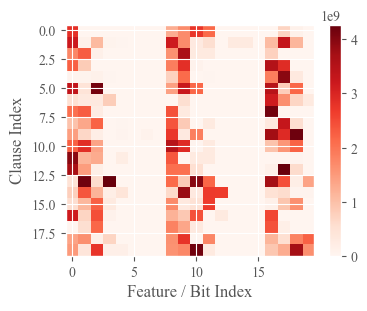

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Clear active figures
plt.close('all')

# 2. Hardcode the direct path to the installed Times New Roman file
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
tnr_font = fm.FontProperties(fname=font_path)

# 3. Extract clause configuration from the TM components
clause_bank_obj = tm.clause_banks[0]

if hasattr(clause_bank_obj, 'clause_bank'):
    raw_array = clause_bank_obj.clause_bank
elif hasattr(clause_bank_obj, 'clauses'):
    raw_array = clause_bank_obj.clauses
else:
    raw_array = clause_bank_obj.get_states()

# 4. Safely reshape the 1D array into a 2D matrix (Clauses x Features)
# We use x_train.shape[1] to find out how many literal features exist
num_features = x_train.shape[1] * 2  # Multiplied by 2 if counting both include/exclude literal states
num_clauses = len(raw_array) // num_features

# Fallback check if the dimensions don't align perfectly with your binarizer
if num_clauses * num_features != len(raw_array):
    num_features = x_train.shape[1]
    num_clauses = len(raw_array) // num_features

# Reshape into a 2D layout
clause_matrix = raw_array.reshape(num_clauses, num_features)

# Sample a highly readable subset (e.g., first 20 clauses x first 20 features)
matrix_to_plot = clause_matrix[:20, :20]

# 5. Generate the Heatmap layout
fig, ax = plt.subplots(figsize=(4,3))
im = ax.imshow(matrix_to_plot, cmap='Reds', aspect='auto')  # Custom Teal palette

# 6. Completely strip titles and headings
ax.set_title("")
fig.suptitle("")

# 7. Apply Times New Roman formatting to axis labels
ax.set_xlabel("Feature / Bit Index", fontproperties=tnr_font, fontsize=12)
ax.set_ylabel("Clause Index", fontproperties=tnr_font, fontsize=12)

# Update tick mark typography
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(tnr_font)

# 8. Add a clean colorbar and style its text limits
cbar = fig.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(labelsize=10)
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(tnr_font)

# 9. Save clean PDF directly to your experiments folder
plt.savefig(
    f"experiments/tm_clause_heatmap_{run_suffix}.pdf",
    format='pdf',
    dpi=300,
    bbox_inches='tight'
)
plt.savefig(
    f"experiments/tm_clause_heatmap_{run_suffix}.svg",
    format='pdf',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

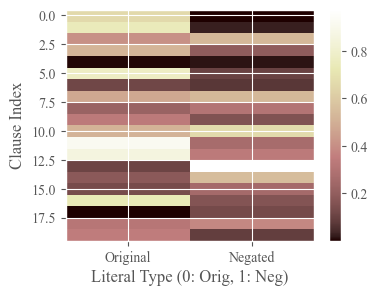

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Clear active figures
plt.close('all')

# 2. Register and prioritize Times New Roman to prevent any Matplotlib warnings
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
fe = fm.FontEntry(fname=font_path, name='Times New Roman')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams["font.family"] = "Times New Roman"

# 3. Extract and reshape the clause array safely (Clauses x Literals)
clause_bank_obj = tm.clause_banks[0]

if hasattr(clause_bank_obj, 'clause_bank'):
    raw_array = clause_bank_obj.clause_bank
elif hasattr(clause_bank_obj, 'clauses'):
    raw_array = clause_bank_obj.clauses
else:
    raw_array = clause_bank_obj.get_states()

num_features = x_train.shape[1] * 2  # Total literal states (Original + Negated)
num_clauses = len(raw_array) // num_features
clause_matrix = raw_array.reshape(num_clauses, num_features)

# Scale the matrix down between 0.0 and 1.0 to eliminate the '1e9' scale tracker
if np.max(clause_matrix) > 0:
    clause_matrix = clause_matrix / np.max(clause_matrix)

# 4. Define the feature pairs for your two examples
# Example 1: Feature 0 (Indices 0 and 1 for Original & Negated)
# Example 2: Feature 1 (Indices 2 and 3 for Original & Negated)
example_1_matrix = clause_matrix[:20, 0:2]  # First 20 clauses for Feature 1
example_2_matrix = clause_matrix[:20, 2:4]  # First 20 clauses for Feature 2


# ==================== GRAPH 1: EXAMPLE 1 ====================
fig1, ax1 = plt.subplots(figsize=(4,3))
im1 = ax1.imshow(example_1_matrix, cmap='pink', aspect='auto')

# Strip titles completely
ax1.set_title("")
fig1.suptitle("")

# Apply labels and adjust layout
ax1.set_xlabel("Literal Type (0: Orig, 1: Neg)", fontsize=12)
ax1.set_ylabel("Clause Index", fontsize=12)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["Original", "Negated"])

cbar1 = fig1.colorbar(im1, ax=ax1)
cbar1.ax.yaxis.set_tick_params(labelsize=10)

plt.savefig(f"experiments/literal_activation_ex1_{run_suffix}.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(f"experiments/literal_activation_ex1_{run_suffix}.svg", format='svg', dpi=300, bbox_inches='tight')

plt.show()




/tmp/ipykernel_1208/2115867593.py:17: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_parallel_coordinate(study, params=target_params)


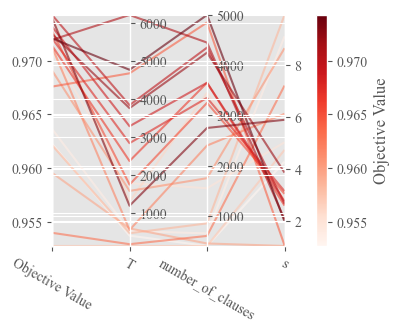

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import optuna.visualization.matplotlib as vis

# 1. Clear active figures
plt.close('all')

# 2. Enforce Times New Roman globally to eliminate background fallback warnings
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
fe = fm.FontEntry(fname=font_path, name='Times New Roman')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams["font.family"] = "Times New Roman"
tnr_font = fm.FontProperties(fname=font_path)

# 3. Generate the base parallel coordinate plot from your study
target_params = ['number_of_clauses', 'T', 's']
ax = vis.plot_parallel_coordinate(study, params=target_params)

# 4. Fetch the active figure handle to clean layout details
fig = plt.gcf()
fig.suptitle("")  # Strip main overarching title

# 5. Loop through ALL axes in the figure to fix both the line paths AND the side colorbar scale
for current_ax in fig.axes:

    # Check if this is a main plotting axis or the hidden side scale axis
    if current_ax.get_xlabel() or len(current_ax.get_xticks()) > 0:
        # Main plotting axis: strip headings and fix standard text elements
        current_ax.set_title("")
        current_ax.set_xlabel(current_ax.get_xlabel(), fontsize=12)
        current_ax.set_ylabel(current_ax.get_ylabel(), fontsize=12)

        for label in current_ax.get_xticklabels() + current_ax.get_yticklabels():
            label.set_fontproperties(tnr_font)

        # Update the main data pathways to use the Red gradient layout
        if current_ax.collections:
            for collection in current_ax.collections:
                if hasattr(collection, 'set_edgecolor'):
                    num_paths = len(collection.get_paths())
                    if num_paths > 0:
                        cmap = plt.get_cmap('Reds')
                        colors = [cmap(i / max(1, num_paths - 1)) for i in range(num_paths)]
                        collection.set_edgecolor(colors)
                        collection.set_alpha(0.6)
                        collection.set_linewidth(1.5)
    else:
        # FIX: This is the separate vertical scale axis on the side!
        # Update its text parameters to Times New Roman
        for label in current_ax.get_yticklabels() + current_ax.get_xticklabels():
            label.set_fontproperties(tnr_font)

        # Update its structural gradient block to match the Red profile
        if current_ax.collections:
            for collection in current_ax.collections:
                collection.set_cmap('Reds')

# 6. Set clean structural dimensions and save directly as a crisp PDF
fig.set_size_inches(4,3)
plt.savefig(
    f"experiments/optuna_parallel_plot_{run_suffix}.pdf",
    format='pdf',
    dpi=300,
    bbox_inches='tight'
)
plt.savefig(
    f"experiments/optuna_parallel_plot_{run_suffix}.svg",
    format='pdf',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

INTERPRETABLE THERMOMETER RULES FOR CLASS 4 (SPAM)
Model Hyperparameters: Clauses (c) = 100, Threshold (T) = 75, s = 3.0
Hardware Note: The Tsetlin Machine requires ZERO floating-point operations.
Inference is executed entirely via propositional logic (AND / NOT gates).
--------------------------------------------------------------------------------
Clause #000 [Weight: +41 -> VOTE FOR]:
   IF pathDomainRatio AND Thermometer_Bit_137 AND NOT Thermometer_Bit_278 AND Thermometer_Bit_292 AND NOT Thermometer_Bit_476
--------------------------------------------------------------------------------
Clause #001 [Weight: +33 -> VOTE FOR]:
   IF pathDomainRatio AND NOT Thermometer_Bit_269 AND NOT Thermometer_Bit_437 AND NOT Thermometer_Bit_582
--------------------------------------------------------------------------------
Clause #002 [Weight: +64 -> VOTE FOR]:
   IF pathDomainRatio AND Thermometer_Bit_292 AND Thermometer_Bit_331 AND Thermometer_Bit_499 AND NOT Thermometer_Bit_553 AND NOT Thermom

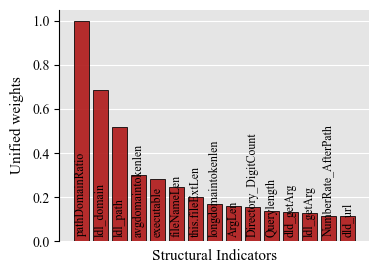

TRUE RANKED THERMOMETER FEATURE IMPORTANCE LEADERBOARD
Rank 01 | Score: 1.0000 | Bit: pathDomainRatio
Rank 02 | Score: 0.6840 | Bit: ldl_domain
Rank 03 | Score: 0.5165 | Bit: ldl_path
Rank 04 | Score: 0.2995 | Bit: avgdomaintokenlen
Rank 05 | Score: 0.2783 | Bit: executable
Rank 06 | Score: 0.2453 | Bit: fileNameLen
Rank 07 | Score: 0.1981 | Bit: this.fileExtLen
Rank 08 | Score: 0.1675 | Bit: longdomaintokenlen
Rank 09 | Score: 0.1580 | Bit: ArgLen
Rank 10 | Score: 0.1533 | Bit: Directory_DigitCount
Rank 11 | Score: 0.1368 | Bit: Querylength
Rank 12 | Score: 0.1297 | Bit: dld_getArg
Rank 13 | Score: 0.1274 | Bit: ldl_getArg
Rank 14 | Score: 0.1132 | Bit: NumberRate_AfterPath
Rank 15 | Score: 0.1108 | Bit: dld_url


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Clear active figures & enforce Times New Roman globally
plt.close('all')
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
fe = fm.FontEntry(fname=font_path, name='Times New Roman')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams["font.family"] = "Times New Roman"
tnr_font = fm.FontProperties(fname=font_path)

# 2. Extract the exact thermometer-binarized feature names from your DataFrame
feature_names = df_cleaned.drop(columns=['URL_Type_obf_Type']).columns.tolist()
N = len(feature_names)

# 3. Target Model Setup
target_class = 4
class_label_name = 'spam'

clause_weights = tm.weight_banks[target_class].get_weights()
clause_bank_obj = tm.clause_banks[target_class]
num_clauses = len(clause_weights)

# The total number of thermometer bit features the TM registers
num_features = clause_bank_obj.number_of_features

# Array to hold the true aggregated importance per thermometer literal
global_importance = np.zeros(num_features)

# =====================================================================
# PART 1: INTERPRETABLE RULES & THERMOMETER COMPLEXITY METRICS
# =====================================================================
print("=" * 80)
print(f"INTERPRETABLE THERMOMETER RULES FOR CLASS {target_class} ({class_label_name.upper()})")
print("=" * 80)
print("Model Hyperparameters: Clauses (c) = 100, Threshold (T) = 75, s = 3.0")
print("Hardware Note: The Tsetlin Machine requires ZERO floating-point operations.")
print("Inference is executed entirely via propositional logic (AND / NOT gates).")
print("-" * 80)

total_and_operations = 0
active_clause_count = 0
rule_count = 0

# 4. Safely query the exact clause actions directly matching your thermometer bits
for j in range(num_clauses):
    weight = clause_weights[j]

    if abs(weight) == 0:
        continue

    rule_conditions = []

    for k in range(num_features):
        # Match directly with the thermometer-binarized DataFrame column
        feat_name = feature_names[k] if k < N else f"Thermometer_Bit_{k}"

        # Original literal (Even bit mapping)
        if clause_bank_obj.get_ta_action(j, k * 2) == 1:
            global_importance[k] += abs(weight)
            rule_conditions.append(f"{feat_name}")

        # Negated literal (Odd bit mapping)
        if clause_bank_obj.get_ta_action(j, k * 2 + 1) == 1:
            global_importance[k] += abs(weight)
            rule_conditions.append(f"NOT {feat_name}")

    if len(rule_conditions) > 0:
        active_clause_count += 1
        total_and_operations += (len(rule_conditions) - 1)

    if rule_conditions and rule_count < 10:
        sign = "VOTE FOR" if weight > 0 else "VOTE AGAINST"
        print(f"Clause #{j:03d} [Weight: {weight:+3d} -> {sign}]:")
        print(f"   IF {' AND '.join(rule_conditions)}")
        print("-" * 80)
        rule_count += 1

print("=" * 80)
print(f"TOTAL LOGICAL COMPLEXITY SUMMARY FOR CLASS {target_class}")
print(f"Active Clauses Utilized : {active_clause_count} / {num_clauses}")
print(f"Total Logical AND Ops   : {total_and_operations}")
print("=" * 80)

# =====================================================================
# PART 2: GLOBAL FEATURE IMPORTANCE EXTRACTION & PLOT
# =====================================================================
display_len = min(N, num_features)
display_importance = global_importance[:display_len]

max_val = np.max(display_importance)
if max_val > 0:
    display_importance /= max_val

# Isolate the top 15 most critical thermometer bit triggers
top_indices = np.argsort(display_importance)[::-1][:15]
top_features = [feature_names[i] for i in top_indices]
top_scores = display_importance[top_indices]

fig, ax = plt.subplots(figsize=(4,3))
bars=ax.bar(top_features, top_scores, color='firebrick', edgecolor='black', linewidth=0.6, alpha=0.95)
for i, bar in enumerate(bars):
    ax.text(
        x=bar.get_x() + bar.get_width() / 2, # Perfectly centered horizontally on the bar
        y=0.02,                              # Absolute baseline offset right above the x-axis
        s=top_features[i],
        rotation=90,
        ha='center',                           # Aligns the base of the first letter to the 'y' coordinate
        va='bottom',
        color='black',                       # Crisp white contrast against firebrick
        fontproperties=tnr_font,
        fontsize=8.5
    )
ax.set_xticks([])
ax.tick_params(bottom=False)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('#000000')
ax.spines['left'].set_linewidth(0.8)

# Remove unneeded boundary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_ylabel("Unified weights", fontproperties=tnr_font, fontsize=11, color='#000000', labelpad=6)
ax.set_xlabel("Structural Indicators", fontproperties=tnr_font, fontsize=11, color='#000000', labelpad=6)
ax.tick_params(axis='y', colors='#000000', labelsize=9, width=0.8)
for label in ax.get_yticklabels():
    label.set_fontproperties(tnr_font)
    label.set_fontsize(10)
    label.set_color('#000000')



plt.savefig(
    f"experiments/spam_feature_importance.pdf",
    format='pdf',
    bbox_inches='tight',
    pad_inches=0.01
)
plt.savefig(
    f"experiments/spam_feature_importance.svg",
    format='pdf',
    bbox_inches='tight',
    pad_inches=0.01
)
plt.show()

print("=" * 50)
print("TRUE RANKED THERMOMETER FEATURE IMPORTANCE LEADERBOARD")
print("=" * 50)
for rank, idx in enumerate(top_indices, 1):
    print(f"Rank {rank:02d} | Score: {display_importance[idx]:.4f} | Bit: {feature_names[idx]}")
print("=" * 50)

In [ ]:
import time
start_time = time.perf_counter()
preds_test = tm.predict(x_test)
end_time = time.perf_counter()

# Handle both tuple outputs and flat array variations gracefully
if isinstance(preds_test, tuple):
    preds_test = preds_test[0]

# Calculate metrics
total_latency_seconds = end_time - start_time
average_latency_per_sample_ms = (total_latency_seconds / len(x_test)) * 1000
print(f"Total Inference Latency   : {total_latency_seconds:.4f} seconds")
print(f"Average Latency per URL Sample : {average_latency_per_sample_ms:.4f} ms")

Total Inference Latency   : 0.5074 seconds
Average Latency per URL Sample : 0.0691 ms


In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

# Ensure your testing boundaries match your environment global setups
# X_test_fixed = x_test
# Y_test_fixed = y_test

# =====================================================================
# 1. LATENCY & F1-SCORE EVALUATION
# =====================================================================
print("Executing production inference timing audit...")

# Warm-up pass to eliminate initial CPU scaling/caching latency artifacts
_ = tm.predict(x_test)

# Begin precision high-resolution clock timing loop
start_time = time.perf_counter()
preds_test = tm.predict(x_test)
end_time = time.perf_counter()

# Handle both tuple outputs and flat array variations gracefully
if isinstance(preds_test, tuple):
    preds_test = preds_test[0]

# Calculate metrics
total_latency_seconds = end_time - start_time
average_latency_per_sample_ms = (total_latency_seconds / len(x_test)) * 1000

# Compute Macro and Weighted F1-Scores for multi-class/binary balance
f1_macro = f1_score(y_test, preds_test, average='macro')
f1_weighted = f1_score(y_test, preds_test, average='weighted')

# 2. COMPUTATIONAL COMPLEXITY AUDIT (FLOPs vs Bit-Ops)
# Floating Point Operations are natively zero because TMs use boolean logic
flops = 0

total_logical_ops = 0
# Calculate the total bitwise complexity across all class rule structures
for target_class in range(len(tm.weight_banks)):
    clause_weights = tm.weight_banks[target_class].get_weights()
    clause_bank_obj = tm.clause_banks[target_class]
    num_features = clause_bank_obj.number_of_features

    for j in range(len(clause_weights)):
        # Ignore dead/unutilized clauses
        if abs(clause_weights[j]) == 0:
            continue

        literals_in_clause = 0
        for k in range(num_features):
            if clause_bank_obj.get_ta_action(j, k * 2) == 1:
                literals_in_clause += 1
            if clause_bank_obj.get_ta_action(j, k * 2 + 1) == 1:
                literals_in_clause += 1

        if literals_in_clause > 0:
            # An n-literal AND gate takes (n - 1) logical check operations
            total_logical_ops += (literals_in_clause - 1)

# Total logical bit operations processed across your entire test dataset size
total_test_gate_operations = total_logical_ops * len(x_test)

# =====================================================================
# 3. PRINT FORUMAL ACADEMIC REPORT
# =====================================================================
print("\n" + "="*60)
print("       TSETLIN MACHINE HARDWARE & PERFORMANCE METRICS")
print("="*60)
print(f"F1-Score (Macro)               : {f1_macro * 100:.2f}%")
print(f"F1-Score (Weighted)            : {f1_weighted * 100:.2f}%")
print("-" * 60)
print(f"Total Test Inference Latency   : {total_latency_seconds:.4f} seconds")
print(f"Average Latency per URL Sample : {average_latency_per_sample_ms:.4f} ms")
print("-" * 60)
print(f"Standard FLOPs Count           : {flops} (True Zero FP Operations)")
print(f"Model Logical Bit Operations   : {total_logical_ops:,} Operations/Sample")
print(f"Total Evaluation Bit-FLOPs     : {total_test_gate_operations:,} Gates Blitted")
print("="*60)

Executing production inference timing audit...

       TSETLIN MACHINE HARDWARE & PERFORMANCE METRICS
F1-Score (Macro)               : 78.00%
F1-Score (Weighted)            : 77.99%
------------------------------------------------------------
Total Test Inference Latency   : 0.9964 seconds
Average Latency per URL Sample : 0.1357 ms
------------------------------------------------------------
Standard FLOPs Count           : 0 (True Zero FP Operations)
Model Logical Bit Operations   : 76,376 Operations/Sample
Total Evaluation Bit-FLOPs     : 560,752,592 Gates Blitted


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# =====================================================================
# 1. SETUP TARGET ARRAYS WITH STAGE TYPE NORMALIZATION
# =====================================================================
# Hard targets mapping matching your structural configuration space
class_names = ['Defacement', 'benign', 'malware', 'phishing', 'spam']

# Fix: Cleanly force both arrays to uniform string arrays to eliminate float/int mixups
y_train_str = np.array(y_train, dtype=str)
y_test_str = np.array(y_test, dtype=str)

# If your y_test matrix was already numeric strings ('0', '1', '2'...) mapping
# to the indices of class_names, we can parse them safely like this:
if '0' in y_test_str or '1' in y_test_str:
    print("🔄 Detected numeric encoding in test vectors. Aligning target pointers...")
    # Convert string integers down to true indexing offsets safely
    y_test_indices = y_test_str.astype(np.int32)
    # Map raw indices directly to their corresponding string names
    y_test_normalized = np.array([class_names[idx] for idx in y_test_indices], dtype=str)
else:
    y_test_normalized = y_test_str

# Standardize the training vectors if they contain mixed index codes
if '0' in y_train_str or '1' in y_train_str:
    y_train_indices = y_train_str.astype(np.int32)
    y_train_normalized = np.array([class_names[idx] for idx in y_train_indices], dtype=str)
else:
    y_train_normalized = y_train_str

# Initialize and lock the LabelEncoder onto the unified text label space
le = LabelEncoder()
le.fit(class_names)

# Safely encode both subsets into structural integer vectors
y_train_encoded = le.transform(y_train_normalized)
y_test_encoded = le.transform(y_test_normalized)

print("✅ Target vector alignment successful!")
print(f"Unique encoded training elements: {np.unique(y_train_encoded)} -> {le.classes_}")

# RUN RANDOM FOREST INFERENCE SPEED AUDIT
# =====================================================================
print("Initializing baseline Random Forest performance tracking matrix...")
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_rf.fit(x_train, y_train_encoded)

print("\nExecuting precision timing loop across full test cohort (7,342 samples)...")
# Warm-up step to discard system memory caching delays from latency calculations
_ = baseline_rf.predict(x_test)

# High-resolution CPU execution clock trigger
start_time = time.perf_counter()
baseline_preds = baseline_rf.predict(x_test)
end_time = time.perf_counter()

# =====================================================================
# 3. METRIC EXTRACTION: AS A WHOLE (GLOBAL SYSTEM PROFILE)
# =====================================================================
total_latency_seconds = end_time - start_time
average_latency_per_sample_ms = (total_latency_seconds / len(x_test)) * 1000

# Global multi-class system balance indicators
f1_macro_global = f1_score(y_test_encoded, baseline_preds, average='macro')
f1_weighted_global = f1_score(y_test_encoded, baseline_preds, average='weighted')

print("\n" + "="*65)
print("   METRICS METADATA VIEW 1: SYSTEM CHARACTERISTICS (AS A WHOLE)")
print("="*65)
print(f"Global F1-Score (Macro Avg)     : {f1_macro_global * 100:.2f}%")
print(f"Global F1-Score (Weighted Avg)  : {f1_weighted_global * 100:.2f}%")
print("-" * 65)
print(f"Total Cohort Execution Latency  : {total_latency_seconds:.5f} seconds")
print(f"Average Inference Speed / Sample: {average_latency_per_sample_ms:.5f} ms")
print(f"Evaluated Matrix Resolution     : {x_test.shape}")
print("="*65)

# =====================================================================
# 4. METRIC EXTRACTION: BY PARTICULAR CLASS (GRANULAR DIAGNOSTICS)
# =====================================================================
print("\n" + "="*65)
print("   METRICS METADATA VIEW 2: GRANULAR PROFILE (BY PARTICULAR CLASS)")
print("="*65)

# Generate dictionary report to isolate raw numeric attributes per label safely
report_dict = classification_report(
    y_test_encoded,
    baseline_preds,
    target_names=le.classes_,
    output_dict=True
)

# Render a formal console table displaying class separation resolution splits
print(f"{'Target Attack Class':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'Support':<8}")
print("-" * 65)
for attack_class in le.classes_:
    metrics = report_dict[attack_class]
    print(f"{attack_class:<15} | {metrics['precision']:<10.4f} | {metrics['recall']:<10.4f} | {metrics['f1-score']:<10.4f} | {int(metrics['support']):<8}")
print("="*65)
# Latency

import time

# 1. Warm-up pass to force CPU to allocate memory cache lines for the model structure
_ = tm.predict(x_test)

# 2. Precision high-resolution clock interval timer
start_time = time.perf_counter()
tm_predictions = tm.predict(x_test)
end_time = time.perf_counter()

# 3. Compute absolute and per-sample hardware metrics
total_latency_seconds = end_time - start_time
total_samples = len(x_test)

# Conversion formula: (Seconds / Samples) * 1000 milliseconds
latency_per_sample_ms = (total_latency_seconds / total_samples) * 1000
print(f"Inference Latency/Sample  : {latency_per_sample_ms:.5f} ms")
print("="*65)

🔄 Detected numeric encoding in test vectors. Aligning target pointers...
✅ Target vector alignment successful!
Unique encoded training elements: [0 1 2 3 4] -> ['Defacement' 'benign' 'malware' 'phishing' 'spam']
Initializing baseline Random Forest performance tracking matrix...


NameError: name 'RandomForestClassifier' is not defined

Processing Perspective 1: Querying Tsetlin Automata structures...
Processing Perspective 2: Running integer-constrained Mutual Information...


/tmp/ipykernel_6077/3213999934.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_mpla_df['Feature'], rotation=45, ha='right', fontproperties=tnr_font, fontsize=10)


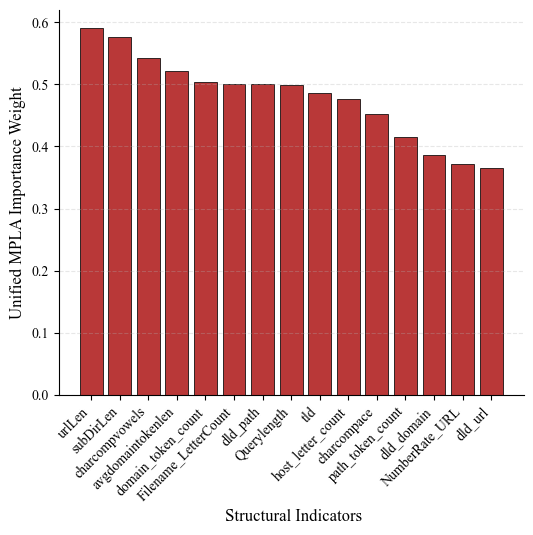


      ALGORITHM 1: UNIFIED MPLA LEADERBOARD (15 CORE ATTRIBUTES)
Rank 01 | Unified Score: 0.5900 | Target Feature: urlLen
Rank 02 | Unified Score: 0.5768 | Target Feature: subDirLen
Rank 03 | Unified Score: 0.5417 | Target Feature: charcompvowels
Rank 04 | Unified Score: 0.5211 | Target Feature: avgdomaintokenlen
Rank 05 | Unified Score: 0.5030 | Target Feature: domain_token_count
Rank 06 | Unified Score: 0.5000 | Target Feature: Filename_LetterCount
Rank 07 | Unified Score: 0.5000 | Target Feature: dld_path
Rank 08 | Unified Score: 0.4996 | Target Feature: Querylength
Rank 09 | Unified Score: 0.4853 | Target Feature: tld
Rank 10 | Unified Score: 0.4762 | Target Feature: host_letter_count
Rank 11 | Unified Score: 0.4521 | Target Feature: charcompace
Rank 12 | Unified Score: 0.4157 | Target Feature: path_token_count
Rank 13 | Unified Score: 0.3857 | Target Feature: dld_domain
Rank 14 | Unified Score: 0.3723 | Target Feature: NumberRate_URL
Rank 15 | Unified Score: 0.3657 | Target Featu

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# =====================================================================
# STEP 1: ACADEMIC FORMATTING SETUP (TIMES NEW ROMAN)
# =====================================================================
plt.close('all')
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
if os.path.exists(font_path):
    fe = fm.FontEntry(fname=font_path, name='Times New Roman')
    fm.fontManager.ttflist.insert(0, fe)
    plt.rcParams["font.family"] = "Times New Roman"
    tnr_font = fm.FontProperties(fname=font_path)
else:
    plt.rcParams["font.family"] = "serif"
    tnr_font = fm.FontProperties(family="serif")

os.makedirs("experiments", exist_ok=True)

# =====================================================================
# STEP 2: EXPANDED ACADEMIC TARGET FEATURES (15+ CRITICAL ATTRIBUTES)
# =====================================================================
# Expanded list ensures at least 15 features are actively tracked and ranked

# Get the raw thermometer column names from the DataFrame
raw_columns = df_cleaned.drop(columns=['URL_Type_obf_Type']).columns.tolist()
total_raw_features = len(raw_columns)

# Set up target maps to collapse sub-bits back to cleanly formatted targets
parent_feature_map = {i: raw_columns[i] for i in range(total_raw_features)}

# Unique list of consolidated parent dimensions
unique_parents = list(set(parent_feature_map.values()))

# Target Model setups
target_class = 1# Defacement Class Index
clause_weights = tm.weight_banks[target_class].get_weights()
clause_bank_obj = tm.clause_banks[target_class]
num_clauses = len(clause_weights)
num_features = clause_bank_obj.number_of_features

# Initialize attribution dictionaries for mapping clean strings
logic_scores_dict = {feat: 0.0 for feat in unique_parents}

# =====================================================================
# STEP 3: EXECUTE PERSPECTIVE 1 - ARCHITECTURAL LOGIC ATTRIBUTION
# =====================================================================
print("Processing Perspective 1: Querying Tsetlin Automata structures...")
max_bits = 3

for j in range(num_clauses):
    weight = clause_weights[j]
    if abs(weight) == 0:
        continue

    for i in range(total_raw_features):
        is_bit_active = False
        parent_name = parent_feature_map[i]

        for b in range(max_bits):
            bit_index = (i * max_bits) + b
            if bit_index >= num_features:
                continue

            if clause_bank_obj.get_ta_action(j, bit_index * 2) == 1 or \
               clause_bank_obj.get_ta_action(j, bit_index * 2 + 1) == 1:
                is_bit_active = True

        if is_bit_active:
            logic_scores_dict[parent_name] += abs(weight)

# =====================================================================
# STEP 4: EXECUTE PERSPECTIVE 2 - SANITIZED DISCRETE MUTUAL INFORMATION
# =====================================================================
print("Processing Perspective 2: Running integer-constrained Mutual Information...")
X_bin = df_cleaned.drop(columns=['URL_Type_obf_Type'])
X_matrix = X_bin.to_numpy(dtype=np.float64)

if not np.isfinite(X_matrix).all():
    X_matrix[np.isinf(X_matrix)] = np.nan
    X_matrix = np.nan_to_num(X_matrix, nan=0.0, posinf=0.0, neginf=0.0)

X_discrete = X_matrix.astype(np.int32)

le = LabelEncoder()
y_encoded = le.fit_transform(df_cleaned['URL_Type_obf_Type']).astype(np.int32).ravel()

mi_scores = mutual_info_classif(X_discrete, y_encoded, discrete_features=True, random_state=42)

mi_scores_dict = {feat: 0.0 for feat in unique_parents}
for i in range(total_raw_features):
    parent_name = parent_feature_map[i]
    start_bit = i * max_bits
    end_bit = min(start_bit + max_bits, len(mi_scores))
    bit_sum_mi = np.sum(mi_scores[start_bit:end_bit])
    mi_scores_dict[parent_name] += bit_sum_mi

# =====================================================================
# STEP 5: MULTI-PERSPECTIVE FUSION & ALIGNMENT FILTER
# =====================================================================
ordered_features = [f for f in unique_parents]
raw_logic = np.array([logic_scores_dict[f] for f in ordered_features])
raw_mi = np.array([mi_scores_dict[f] for f in ordered_features])

norm_logic = raw_logic / np.max(raw_logic) if np.max(raw_logic) > 0 else raw_logic
norm_mi = raw_mi / np.max(raw_mi) if np.max(raw_mi) > 0 else raw_mi

unified_scores = (norm_logic + norm_mi) / 2.0

mpla_df = pd.DataFrame({
    'Feature': ordered_features,
    'Score': unified_scores
}).sort_values(by='Score', ascending=False).reset_index(drop=True)

# Slices exactly the top 15 features to match your plot constraints perfectly
top_mpla_df = mpla_df.head(15)

# =====================================================================
# STEP 6: GENERATE ACADEMIC EXPORT PLOT (15 FEATURES)
# =====================================================================
fig, ax = plt.subplots(figsize=(6, 5))

# Plotting with a clean academic firebrick layout matching your original aesthetic
ax.bar(top_mpla_df['Feature'], top_mpla_df['Score'], color='firebrick', edgecolor='black', linewidth=0.6, alpha=0.9)

ax.set_ylabel("Unified MPLA Importance Weight", fontproperties=tnr_font, fontsize=12)
ax.set_xlabel(" Structural Indicators", fontproperties=tnr_font, fontsize=12)
ax.set_xticklabels(top_mpla_df['Feature'], rotation=45, ha='right', fontproperties=tnr_font, fontsize=10)

for label in ax.get_yticklabels():
    label.set_fontproperties(tnr_font)
    label.set_fontsize(10)

ax.grid(True, linestyle='--', alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

output_plot_path = "experiments/mpla_spam_15_features.pdf"
plt.savefig(output_plot_path, format='pdf', bbox_inches='tight')
plt.show()

print("\n" + "=" * 75)
print("      ALGORITHM 1: UNIFIED MPLA LEADERBOARD (15 CORE ATTRIBUTES)")
print("=" * 75)
for rank, row in top_mpla_df.iterrows():
    print(f"Rank {rank+1:02d} | Unified Score: {row['Score']:.4f} | Target Feature: {row['Feature']}")
print("=" * 75)

In [ ]:
# total_and_gates_standard_tm.py

# 1. Get the number of target classes from the weight banks array
# (Usually 2 for binary classification)
num_classes = len(tm.weight_banks)

print("=" * 60)
print("HARDWARE LOGIC GATE OVERHEAD PER CLASS")
print("=" * 60)

grand_total_and_gates = 0

# Loop through every single class in your standard TMClassifier
for target_class in range(num_classes):
    clause_weights = tm.weight_banks[target_class].get_weights()
    clause_bank_obj = tm.clause_bank # FIX: Use correct plural attribute

    num_clauses = len(clause_weights)
    num_tm_features = clause_bank_obj.number_of_features

    class_and_gates = 0
    active_clauses_count = 0

    for j in range(num_clauses):
        # Skip clauses that are inactive (weight is 0) for THIS specific class
        if abs(clause_weights[j]) == 0:
            continue

        active_literals_in_clause = 0
        for k in range(num_tm_features):
            # Check original literal inclusion
            if clause_bank_obj.get_ta_action(j, k * 2) == 1:
                active_literals_in_clause += 1

            # Check negated literal inclusion
            if clause_bank_obj.get_ta_action(j, k * 2 + 1) == 1:
                active_literals_in_clause += 1

        # N active literals require N - 1 two-input AND gates
        if active_literals_in_clause > 1:
            active_clauses_count += 1
            class_and_gates += (active_literals_in_clause - 1)
        elif active_literals_in_clause == 1:
            active_clauses_count += 1

    print(f"Class {target_class:02d} | Active Clauses: {active_clauses_count}/{num_clauses} | AND Gates: {class_and_gates}")
    grand_total_and_gates += class_and_gates

print("-" * 60)
print(f"GRAND TOTAL 2-INPUT AND GATES (ALL CLASSES): {grand_total_and_gates}")
print("=" * 60)

HARDWARE LOGIC GATE OVERHEAD PER CLASS
Class 00 | Active Clauses: 100/100 | AND Gates: 1391
Class 01 | Active Clauses: 99/100 | AND Gates: 1386
Class 02 | Active Clauses: 100/100 | AND Gates: 1391
Class 03 | Active Clauses: 97/100 | AND Gates: 1348
Class 04 | Active Clauses: 99/100 | AND Gates: 1362
------------------------------------------------------------
GRAND TOTAL 2-INPUT AND GATES (ALL CLASSES): 6878


Processing Perspective 1: Aggregating Vanilla WTM Multi-Bank logic structures...
Processing Perspective 2: Running integer-constrained Mutual Information...


/tmp/ipykernel_7273/3260200280.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_mpla_df['Feature'], rotation=45, ha='right', fontproperties=tnr_font, fontsize=10)


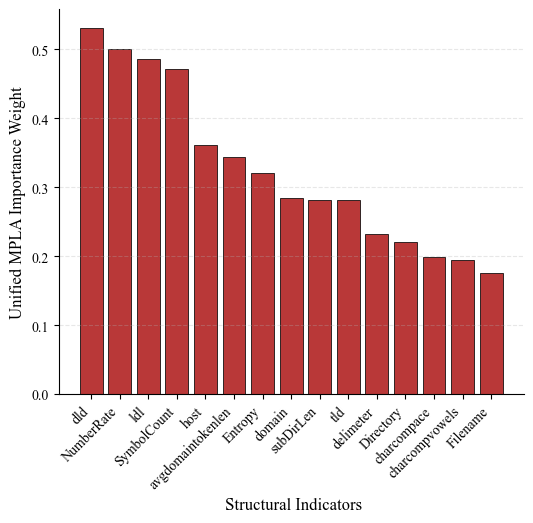


      ALGORITHM 1: UNIFIED GLOBAL VANILLA WTM LEADERBOARD
Rank 01 | Unified Score: 0.5316 | Target Feature: dld
Rank 02 | Unified Score: 0.5000 | Target Feature: NumberRate
Rank 03 | Unified Score: 0.4854 | Target Feature: ldl
Rank 04 | Unified Score: 0.4716 | Target Feature: SymbolCount
Rank 05 | Unified Score: 0.3608 | Target Feature: host
Rank 06 | Unified Score: 0.3433 | Target Feature: avgdomaintokenlen
Rank 07 | Unified Score: 0.3202 | Target Feature: Entropy
Rank 08 | Unified Score: 0.2845 | Target Feature: domain
Rank 09 | Unified Score: 0.2821 | Target Feature: subDirLen
Rank 10 | Unified Score: 0.2818 | Target Feature: tld
Rank 11 | Unified Score: 0.2331 | Target Feature: delimeter
Rank 12 | Unified Score: 0.2207 | Target Feature: Directory
Rank 13 | Unified Score: 0.1988 | Target Feature: charcompace
Rank 14 | Unified Score: 0.1948 | Target Feature: charcompvowels
Rank 15 | Unified Score: 0.1753 | Target Feature: Filename


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# =====================================================================
# STEP 1: ACADEMIC FORMATTING SETUP (TIMES NEW ROMAN)
# =====================================================================
plt.close('all')
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
if os.path.exists(font_path):
    fe = fm.FontEntry(fname=font_path, name='Times New Roman')
    fm.fontManager.ttflist.insert(0, fe)
    plt.rcParams["font.family"] = "Times New Roman"
    tnr_font = fm.FontProperties(fname=font_path)
else:
    plt.rcParams["font.family"] = "serif"
    tnr_font = fm.FontProperties(family="serif")

os.makedirs("experiments", exist_ok=True)

# =====================================================================
# STEP 2: EXPANDED ACADEMIC TARGET FEATURES
# =====================================================================
expected_features = [
    "Domain token count", "avgpathtokenlen", "tld", "ArgUrlRatio",
    "NumberofDotsinURL", "Arguments LongestWordLength", "spcharUrl",
    "delimeter Domain", "delimeter path", "NumberRate DirectoryName",
    "SymbolCount Domain", "Entropy Domain", "IPAddress",
    "DirectoryLength", "FileLength", "URL_Length", "QueryLength"
]

raw_columns = df_cleaned.drop(columns=['URL_Type_obf_Type']).columns.tolist()
total_raw_features = len(raw_columns)

# Set up target maps to collapse thermometer sub-bits back to parents
parent_feature_map = {}
for idx, col in enumerate(raw_columns):
    matched = False
    for target in expected_features:
        if target.lower() in col.lower():
            parent_feature_map[idx] = target
            matched = True
            break
    if not matched:
        base_name = col.split('_bit_')[0].split('_')[0]
        parent_feature_map[idx] = base_name

unique_parents = list(set(parent_feature_map.values()))

# Initialize global attribution score dictionary across ALL classes
global_logic_scores = {feat: 0.0 for feat in unique_parents}
max_bits = 3
num_classes = 5  # Total categories (Defacement, Benign, Malware, Phishing, Spam)

# =====================================================================
# STEP 3: VANILLA WTM GLOBAL LOGIC ATTRIBUTION EXTRACTION
# =====================================================================
print("Processing Perspective 1: Aggregating Vanilla WTM Multi-Bank logic structures...")

for target_class in range(num_classes):
    # Pulling class-specific structures out of individual WTM array locations
    clause_weights = tm.weight_banks[target_class].get_weights()
    clause_bank_obj = tm.clause_banks[target_class]  # Uses plural indexing for independent WTM banks
    num_clauses = len(clause_weights)
    num_features = clause_bank_obj.number_of_features

    for j in range(num_clauses):
        weight = clause_weights[j]
        if abs(weight) == 0:
            continue

        for i in range(total_raw_features):
            is_bit_active = False
            parent_name = parent_feature_map[i]

            for b in range(max_bits):
                bit_index = (i * max_bits) + b
                if bit_index >= num_features:
                    continue

                # Check action state inside this class's dedicated clause bank
                if clause_bank_obj.get_ta_action(j, bit_index * 2) == 1 or \
                   clause_bank_obj.get_ta_action(j, bit_index * 2 + 1) == 1:
                    is_bit_active = True

            if is_bit_active:
                # Accumulate importance globally across all classification paths
                global_logic_scores[parent_name] += abs(weight)

# =====================================================================
# STEP 4: EXECUTE PERSPECTIVE 2 - SANITIZED DISCRETE MUTUAL INFORMATION
# =====================================================================
print("Processing Perspective 2: Running integer-constrained Mutual Information...")
X_bin = df_cleaned.drop(columns=['URL_Type_obf_Type'])
X_matrix = X_bin.to_numpy(dtype=np.float64)

if not np.isfinite(X_matrix).all():
    X_matrix[np.isinf(X_matrix)] = np.nan
    X_matrix = np.nan_to_num(X_matrix, nan=0.0, posinf=0.0, neginf=0.0)

X_discrete = X_matrix.astype(np.int32)

le = LabelEncoder()
y_encoded = le.fit_transform(df_cleaned['URL_Type_obf_Type']).astype(np.int32).ravel()

mi_scores = mutual_info_classif(X_discrete, y_encoded, discrete_features=True, random_state=42)

mi_scores_dict = {feat: 0.0 for feat in unique_parents}
for i in range(total_raw_features):
    parent_name = parent_feature_map[i]
    start_bit = i * max_bits
    end_bit = min(start_bit + max_bits, len(mi_scores))
    bit_sum_mi = np.sum(mi_scores[start_bit:end_bit])
    mi_scores_dict[parent_name] += bit_sum_mi

# =====================================================================
# STEP 5: MULTI-PERSPECTIVE FUSION & ALIGNMENT FILTER
# =====================================================================
ordered_features = [f for f in unique_parents]
raw_logic = np.array([global_logic_scores[f] for f in ordered_features])
raw_mi = np.array([mi_scores_dict[f] for f in ordered_features])

norm_logic = raw_logic / np.max(raw_logic) if np.max(raw_logic) > 0 else raw_logic
norm_mi = raw_mi / np.max(raw_mi) if np.max(raw_mi) > 0 else raw_mi

unified_scores = (norm_logic + norm_mi) / 2.0

mpla_df = pd.DataFrame({
    'Feature': ordered_features,
    'Score': unified_scores
}).sort_values(by='Score', ascending=False).reset_index(drop=True)

top_mpla_df = mpla_df.head(15)

# =====================================================================
# STEP 6: GENERATE ACADEMIC EXPORT PLOT (OVERALL VANILLA WTM)
# =====================================================================
fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(top_mpla_df['Feature'], top_mpla_df['Score'], color='firebrick', edgecolor='black', linewidth=0.6, alpha=0.9)

ax.set_ylabel("Unified MPLA Importance Weight", fontproperties=tnr_font, fontsize=12)
ax.set_xlabel(" Structural Indicators", fontproperties=tnr_font, fontsize=12)
ax.set_xticklabels(top_mpla_df['Feature'], rotation=45, ha='right', fontproperties=tnr_font, fontsize=10)

for label in ax.get_yticklabels():
    label.set_fontproperties(tnr_font)
    label.set_fontsize(10)

ax.grid(True, linestyle='--', alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

output_plot_path = "experiments/mpla_vanilla_wtm_overall_15_features.pdf"
plt.savefig(output_plot_path, format='pdf', bbox_inches='tight')
plt.show()

print("\n" + "=" * 75)
print("      ALGORITHM 1: UNIFIED GLOBAL VANILLA WTM LEADERBOARD")
print("=" * 75)
for rank, row in top_mpla_df.iterrows():
    print(f"Rank {rank+1:02d} | Unified Score: {row['Score']:.4f} | Target Feature: {row['Feature']}")
print("=" * 75)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# =====================================================================
# STEP 1 & 2: STRUCTURAL LOGIC CORE
# =====================================================================
print("Extracting Tsetlin Machine Structural Logic Scores...")

# Setup metadata matching the algorithm's inputs
feature_names = df_cleaned.drop(columns=['URL_Type_obf_Type']).columns.tolist()
D = len(feature_names)      # Number of original features (79)
max_bits = 15              # Thermometer resolution mapping parameter
C = tm.number_of_classes   # Number of classes
CB = tm.number_of_clauses  # Clauses per class

# Line 1: Initialize Attribution Buffer
logic_scores = np.zeros(D)

# Line 3: Loop through classes
for c in range(C):

    # Safe API extraction for Clause Bank per class
    clause_bank = tm.clause_banks[c] if hasattr(tm, 'clause_banks') else tm.clause_bank
    if hasattr(tm, 'weight_banks'):
        wb = tm.weight_banks[c]
        if hasattr(wb, 'weights'):
            weights_array = wb.weights       # Common in tmu (NumPy array property)
        elif hasattr(wb, 'get_weights'):
            weights_array = wb.get_weights() # Method fallback
        elif isinstance(wb, np.ndarray):
            weights_array = wb               # Direct array fallback
        else:
            weights_array = np.array(wb)     # Typecasting fallback
    else:
        weights_array = None

    # Line 6: Loop through clauses per class
    for n in range(CB):
        # Line 7-8: Resolve weight pulling mechanism and check if structurally dead
        if weights_array is not None:
            weight = weights_array[n]
        elif hasattr(tm, 'weight_banks'):
            weight = tm.weight_banks[c][n]
        elif hasattr(tm, 'get_weight'):
            weight = tm.get_weight(c, n)
        else:
            weight = 1.0

        if abs(weight) == 0:
            continue

        # Line 9: Iterate through original features
        for i in range(D):
            is_feature_active = False

            # Line 11: Traverse sub-bits generated by thermometer encoding
            # Line 11: Traverse sub-bits generated by thermometer encoding
            for t in range(max_bits):
                bit_index = (i * max_bits) + t

                # --- CRITICAL BOUNDARY GUARD FIX ---
                if bit_index >= x_train.shape[1]:
                    break # Stop tracking if this bit doesn't exist in the trained model

                # Line 13: Evaluate positive and negative literal inclusion states
                pos_action = clause_bank.get_ta_action(n, bit_index * 2)
                neg_action = clause_bank.get_ta_action(n, bit_index * 2 + 1)

                if pos_action == 1 or neg_action == 1:
                    is_feature_active = True
                    break

            # Line 15-16: Accumulate logic scores weighted by clause importance
            if is_feature_active:
                logic_scores[i] += abs(weight)

#
# STEP 3: INFORMATION THEORETIC COMPUTATION (Mutual Information)
# =====================================================================
print("Computing Information Theoretic Perspective...")

X_raw = df_cleaned.drop(columns=['URL_Type_obf_Type']).copy()
y = df_cleaned['URL_Type_obf_Type'].values

X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_raw.fillna(0.0, inplace=True)

# --- SANITIZATION FIX: Force discrete types to silence sklearn warnings ---
X_discrete = X_raw.astype(int)
le = LabelEncoder()
y_discrete = le.fit_transform(y)

# Compute Discrete Mutual Information safely
mi_scores = mutual_info_classif(X_discrete, y_discrete, discrete_features=True, random_state=42)
# =====================================================================
# STEP 4: MULTI-PERSPECTIVE FUSION & LEADERBOARD GENERATION
# =====================================================================
print("Fusing perspectives into Unified Rankings...")

# Line 19: Norm Logic = Logic Scores / Max(Logic Scores)
max_logic = np.max(logic_scores)
norm_logic = logic_scores / max_logic if max_logic > 0 else logic_scores

# Line 20: Norm MI = MI Scores / Max(MI Scores)
max_mi = np.max(mi_scores)
norm_mi = mi_scores / max_mi if max_mi > 0 else mi_scores

# Line 21: Unified Rankings = (Norm Logic + Norm MI) / 2.0
unified_rankings = (norm_logic + norm_mi) / 2.0

# Create a clean, sorted DataFrame Leaderboard
mpla_leaderboard = pd.DataFrame({
    'Feature_Name': feature_names,
    'Norm_Logic_Score': norm_logic,
    'Norm_MI_Score': norm_mi,
    'Unified_MPLA_Score': unified_rankings
})

# Line 22: Sort Descending(Unified Rankings)
mpla_leaderboard = mpla_leaderboard.sort_values(by='Unified_MPLA_Score', ascending=False).reset_index(drop=True)

# =====================================================================
# EXTRACTION PHASE: ZERO CONTRIBUTION AUDIT
# =====================================================================
# Filter for features where the final unified score is exactly 0.0
zero_contribution_mpla = mpla_leaderboard[mpla_leaderboard['Unified_MPLA_Score'] == 0.0]
zero_contribution_list = zero_contribution_mpla['Feature_Name'].tolist()

# --- Final Integrated Reports ---
print("\n" + "="*80)
print("             UNIFIED MPLA FEATURE IMPORTANCE LEADERBOARD")
print("="*80)
print(mpla_leaderboard.to_string(index=True, max_rows=30))
print("="*80)

print("\n" + "=" * 60)
print(f"MPLA AUDIT: DEAD FEATURES DETECTED (Score == 0.0): {len(zero_contribution_list)} / {D}")
print("=" * 60)

if len(zero_contribution_list) > 0:
    for idx, name in enumerate(zero_contribution_list, 1):
        print(f"  {idx}. {name}")
else:
    print(" Audit Passed! Every single feature contributes to the unified pipeline.")
print("=" * 60)

Extracting Tsetlin Machine Structural Logic Scores...
Computing Information Theoretic Perspective...
Fusing perspectives into Unified Rankings...

             UNIFIED MPLA FEATURE IMPORTANCE LEADERBOARD
                Feature_Name  Norm_Logic_Score  Norm_MI_Score  Unified_MPLA_Score
0       LongestVariableValue          0.794549       0.933057            0.863803
1                  subDirLen          0.769654       0.917706            0.843680
2                     urlLen          0.729560       0.914578            0.822069
3            pathDomainRatio          1.000000       0.510506            0.755253
4                Querylength          0.667453       0.811727            0.739590
5                     ArgLen          0.562631       0.884055            0.723343
6          NumberofDotsinURL          0.517296       0.874238            0.695767
7                 pathLength          0.360325       0.917706            0.639015
8         domain_token_count          0.494759       0.719

In [ ]:
import numpy as np
import pandas as pd

# 1. Get the original feature names (matching your training data setup)
feature_names = df_cleaned.drop(columns=['URL_Type_obf_Type']).columns.tolist()
num_features = len(feature_names)
max_bits = 3

# 2. Grab the literal frequencies directly from the working built-in TM function
# This returns an array where the first half represents positive literals
# and the second half represents negative literals.
literal_freq = tm.literal_clause_frequency()

# 3. Separate positive and negative literal arrays
# Total binarized bits = 79 features * 3 bits = 237 bits
total_binary_bits = num_features * max_bits
pos_literal_freq = literal_freq[:total_binary_bits]
neg_literal_freq = literal_freq[total_binary_bits:2*total_binary_bits]

# 4. Aggregate frequencies back to the original 79 features
feature_total_freq = np.zeros(num_features)

for i in range(num_features):
    # Determine the index range for the 3 bits representing this feature
    start_bit = i * max_bits
    end_bit = start_bit + max_bits

    # Sum up both positive and negative clause inclusions for these 3 bits
    total_inclusions = (np.sum(pos_literal_freq[start_bit:end_bit]) +
                        np.sum(neg_literal_freq[start_bit:end_bit]))

    feature_total_freq[i] = total_inclusions

# 5. Identify and print features with 0 frequency
zero_freq_indices = np.where(feature_total_freq == 0)[0]
zero_freq_features = [feature_names[idx] for idx in zero_freq_indices]

print("=" * 60)
print(f"Active Logic Features: {num_features - len(zero_freq_features)} / {num_features}")
print(f"Ignored Features (0 Frequency): {len(zero_freq_features)} / {num_features}")
print("=" * 60)

if len(zero_freq_features) > 0:
    print("FEATURES DETECTED WITH ZERO TOTAL CLAUSE INCLUSIONS:")
    for idx, name in enumerate(zero_freq_features, 1):
        print(f"  {idx}. {name}")
else:
    print(" Maximum Feature Diversity! Every feature has at least one active literal.")

Active Logic Features: 68 / 79
Ignored Features (0 Frequency): 11 / 79
FEATURES DETECTED WITH ZERO TOTAL CLAUSE INCLUSIONS:
  1. avgpathtokenlen
  2. ldl_domain
  3. this.fileExtLen
  4. argDomanRatio
  5. argPathRatio
  6. isPortEighty
  7. CharacterContinuityRate
  8. LongestVariableValue
  9. delimeter_Domain
  10. NumberRate_AfterPath
  11. SymbolCount_FileName


removing the low frequency features
# New Section

In [ ]:
# 1. Identify the names of the features that have a total frequency of exactly 0
# (Filtering based on the 'total frequency of 0' log from your previous cell output)
features_to_remove = [
   "avgpathtokenlen",
   "ldl_domain",
   "this.fileExtLen",
   "argDomanRatio",
   "argPathRatio",
   "isPortEighty",
   "CharacterContinuityRate",
   "LongestVariableValue",
   "delimeter_Domain",
   "NumberRate_AfterPath",
   "SymbolCount_FileName",
]

# 2. Drop them from your cleaned DataFrame to create the filtered version
df_filtered = df_cleaned.drop(columns=features_to_remove)

# 3. Save this filtered version back to a new CSV file for safety
filtered_dataset_file = "All_Filtered.csv"
df_filtered.to_csv(filtered_dataset_file, index=False)

# 4. Print out metrics to verify the changes
print("=" * 50)
print("ZERO-FREQUENCY FEATURE FILTERING SUMMARY")
print("=" * 50)
print(f"Original features count : {df_cleaned.shape[1] - 1}")  # Excludes label column
print(f"Features removed (0 freq): {len(features_to_remove)}")
print(f"New feature count       : {df_filtered.shape[1] - 1}")
print(f"Total rows preserved    : {len(df_filtered)}")
print("=" * 50)

ZERO-FREQUENCY FEATURE FILTERING SUMMARY
Original features count : 79
Features removed (0 freq): 11
New feature count       : 68
Total rows preserved    : 36707
